In [1]:
import pandas as pd
import numpy as np
import sqlite3 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
#importing data 

In [3]:
#connecting Database of Sql
conn =sqlite3.connect('customer_churn.db')

In [4]:
sql_query='''
select name 
from sqlite_master
where type='table'
'''
tables=pd.read_sql(sql_query,conn)

In [5]:
#create database for each table
for table_name in tables['name']:
    df=pd.read_sql(f"select *from {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f'Created DataFrame:df_{table_name}')
    
conn.close()

Created DataFrame:df_db_customer
Created DataFrame:df_db_subscription
Created DataFrame:df_db_support


In [6]:
#2 data cleaning 

In [7]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [8]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [9]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [10]:
# a. drop column - interest and pincode
# b rename column
# c change dob datatype
# d fix missing values country
# e data standardization -gender

In [11]:
# a.rename col - name 
df_db_customer.rename(columns ={'name' :'customer_name'},inplace=True)

In [12]:
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [13]:
#remove columns
df_db_customer.drop('interests',axis=1,inplace=True)


In [14]:
df_db_customer.drop('pincode',axis=1,inplace=True)
# drop column by index
#df_db_customer.drop(df_db_customer.columns[-2:],axis=1,inplace=True)

In [15]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [16]:
#changing DataType
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [17]:
df_db_customer['dob'].dtype

dtype('<M8[us]')

In [18]:
df_db_customer['dob']

0    1982-04-12
1    1995-11-23
2    1978-02-15
3    2001-08-30
4    1990-05-05
5    1988-12-10
6    1976-09-21
7    1999-03-14
8    1985-07-07
9    1993-10-29
10   1997-01-22
11   1981-06-18
12   2004-12-01
13   1992-04-25
14   1979-11-11
15   1986-02-28
16   1994-08-19
17   2000-09-02
18   1983-12-30
19   1991-05-14
20   1977-10-06
Name: dob, dtype: datetime64[us]

In [19]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [20]:
#data standardization-gender
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

In [21]:
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})

In [22]:
df_db_customer['gender']

0       Male
1       Male
2     Female
3       Male
4     Female
5     Female
6     Female
7       Male
8     Female
9       Male
10      Male
11    Female
12    Female
13    Female
14      Male
15    Female
16    Female
17    Female
18      Male
19      Male
20    Female
Name: gender, dtype: str

In [23]:
# fix missing value - country
df_db_customer['country'].unique()

<StringArray>
['India', nan, 'Nepal']
Length: 3, dtype: str

In [24]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [25]:
# country and state - unique vaalue pair

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [26]:
df_db_customer['country']

0     India
1     India
2     India
3     India
4     India
5     India
6     India
7     India
8     Nepal
9     Nepal
10    India
11    India
12    India
13    India
14    India
15    India
16    India
17    India
18    India
19    India
20    India
Name: country, dtype: str

In [27]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        21 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [28]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [29]:
df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,NaN,NaN,20.99,550,62
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,NaN,NaN,13.99,840,27
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaN,NaN,22.99,1955,7
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaN,NaN,13.99,790,47


In [30]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [31]:
date_col=['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [32]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [33]:
df_db_support.head()


,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [34]:
df_db_support.tail()

,customerid,complaint_date,escalations,csat_score,col_1,comment
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,NaN
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,NaN
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,NaN
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [35]:
df_db_support=df_db_support.drop('col_1',axis=1)

In [36]:
df_db_support.drop(columns=['comment'],inplace=True)

In [37]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28 00:00:00,N,60
1,0003-MKNFE,2024-08-28 00:00:00,Y,10
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20
3,0013-MHZWF,2025-03-18 00:00:00,N,90
4,0013-SMEOE,2024-11-01 00:00:00,N,30
5,0017-IUDMW,2024-04-10 00:00:00,Y,25
6,0019-EFAEP,2024-09-27 00:00:00,Y,30
7,0022-TCJCI,2024-09-13 00:00:00,Y,10
8,0022-TCJCI,2024-09-14 00:00:00,N,90


In [38]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      9 non-null      str  
 1   complaint_date  9 non-null      str  
 2   escalations     9 non-null      str  
 3   csat_score      9 non-null      int64
dtypes: int64(1), str(3)
memory usage: 420.0 bytes


In [39]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [40]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [41]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [42]:
#3 . feature engineering and data analysts

In [43]:
# create a new column using exciting column-churn flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [44]:
df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22,0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5,0
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34,0
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,41,0


In [45]:
df_merge=(df_db_subscription.merge(df_db_customer,on='customerid',how='left')
 .merge(df_db_support,on='customerid',how='left'))

In [46]:
df_merge.shape

(23, 20)

In [47]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [48]:
df_db_support.shape

(9, 4)

In [49]:
df_db_support['customerid'].nunique()

7

In [50]:
df_db_support['customerid']

0    0003-MKNFE
1    0003-MKNFE
2    0013-EXCHZ
3    0013-MHZWF
4    0013-SMEOE
5    0017-IUDMW
6    0019-EFAEP
7    0022-TCJCI
8    0022-TCJCI
Name: customerid, dtype: str

In [51]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [52]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [53]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [54]:
df_merge=(df_db_subscription.merge(df_db_customer,on='customerid',how='left')
 .merge(df_db_support,on='customerid',how='left'))

In [55]:
df_merge.shape

(21, 21)

In [56]:
#data analysis

df_merge.to_csv('mergeData.csv',index=False)

In [57]:
df_merge.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [58]:
#churn Rate
churn_rate = df_merge['churn_flag'].mean()*100
print('churn_rate =',round(churn_rate,2),'%') 

churn_rate = 28.57 %


In [59]:
#retention Rate
retention_rate=100-churn_rate
print('retention_rate= ',round(retention_rate,2))

retention_rate=  71.43


In [60]:
#churn by plan type 
churn_by_plan=(df_merge.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [61]:
#churn by state + sum (revenue) & count of users 

churn_by_state=(df_merge.groupby('state').agg(revenue=('monthly_charges','sum'),total_users=('customerid','count')).round(2).reset_index())

In [62]:
churn_by_state

,state,revenue,total_users
0,Delhi,52.96,4
1,Karnataka,20.98,2
2,Kathmandu,20.98,2
3,Maharashtra,50.97,3
4,Meghalaya,42.97,3
5,Nagaland,22.99,1
6,Rajasthan,36.98,2
7,Telangana,30.98,2
8,Uttar Pradesh,115.98,2


In [63]:
#churn by subscription type +sum(revenue)+count of users

churn_by_subscription =(df_merge.groupby('plan_type').agg(revenue=('monthly_charges','sum'),users=('customerid','count')).round(2).reset_index())


In [64]:
churn_by_subscription

,plan_type,revenue,users
0,Basic,52.95,5
1,Premium,218.93,7
2,Standard,123.91,9


In [65]:
average_Revenue=df_merge['monthly_charges'].mean()
print('average_Revenue=',round(average_Revenue,2),'%')

average_Revenue= 18.85 %


In [66]:
df_merge.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [67]:
#count of days user used our services 
tenure = pd.Timestamp.today()
df_merge['tenure_days']=np.where(
    df_merge['cancellation_date'].notna(),
    (df_merge['cancellation_date']-df_merge['subscription_start_date']).dt.days,
    (tenure-df_merge['subscription_start_date']).dt.days
)

In [68]:

avg_days=df_merge['tenure_days'].mean()
print("avg_days(days)=",round(avg_days,0))


avg_days(days)= 1541.0


In [69]:
 avg_days.round(2)

np.float64(1540.86)

In [70]:
#customer age
df_merge['customer_age']=(tenure-df_merge['dob']).dt.days

In [71]:
df_merge['customer_age']

0     16229
1     11256
2     17746
3      9149
4     13284
5     13795
6     18258
7     10049
8     15047
9     12011
10    10830
11    16527
12     7960
13    12563
14    17112
15    14811
16    11717
17     9511
18    15602
19    12910
20    17878
Name: customer_age, dtype: int64

In [72]:
#revenue at risk
revenue_at_risk=df_merge.loc[df_merge['churn_flag']==1,'monthly_charges'].sum()
print('revenue_at_risk (Rs K) =',revenue_at_risk)

revenue_at_risk (Rs K) = 73.94


In [73]:
 # Esclation Rate
escalations_rate=(df_merge['escalations']=='Y').mean()*100
print('escalations Rate =',round(escalations_rate,2),'%')
df_merge['escalations']

escalations Rate = 19.05 %


0     NaN
1       Y
2     NaN
3     NaN
4       Y
5       N
6       N
7     NaN
8     NaN
9     NaN
10    NaN
11      Y
12    NaN
13      Y
14    NaN
15    NaN
16    NaN
17    NaN
18      N
19    NaN
20    NaN
Name: escalations, dtype: str

In [74]:
# Average complaint per user
average_complaint=df_merge['complaint_count'].sum()/df_merge['customerid'].nunique()
print('Customer Complaint Rate =',round(average_complaint,2))


Customer Complaint Rate = 0.43


In [75]:
# correlation escalation vs churn
df_merge['escalations']=np.where(
df_merge['escalations']=='Y',1,0
)
#using correlation
corr_df=df_merge[['escalations','churn_flag']].dropna()
correlation=corr_df['escalations'].corr(df_merge['churn_flag'])
print('correlation between escalations and churn Flag is  =',round(correlation,2),'%')

correlation between escalations and churn Flag is  = 0.77 %


In [76]:
#CHURN RISK CREATE COLUMN USING EXISTING COL
conditions=[(df_merge['churn_score']<50),
            (df_merge['churn_score']>=50) & (df_merge['churn_score']<70),
            (df_merge['churn_score']>=70)]
choices=['low','medium','high']
df_merge['churn_risk']=np.select(conditions,choices,default='unknown')

In [77]:
#visualisation using matplotlib


In [78]:
df_visual=df_merge.copy()

In [79]:
df_visual

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,customer_age,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2012.0,16229,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,11256,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1397.0,17746,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2687.0,9149,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,13284,high
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,...,Delhi,Female,1988-12-10,2025-03-18,0,90.0,1.0,1552.0,13795,low
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,Meghalaya,Female,1976-09-21,2024-11-01,0,30.0,1.0,1142.0,18258,high
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,...,Rajasthan,Male,1999-03-14,NaT,0,NaN,NaN,2407.0,10049,low
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,...,Kathmandu,Female,1985-07-07,NaT,0,NaN,NaN,1153.0,15047,low
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,...,Kathmandu,Male,1993-10-29,NaT,0,NaN,NaN,1628.0,12011,low


In [80]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'customer_age', 'churn_risk'],
      dtype='str')

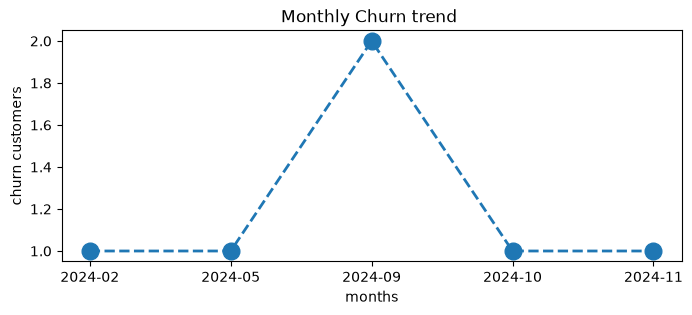

In [81]:
#monthly churn trend (time series KPI)
df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')

churn_trend=df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()
plt.figure(figsize=(8,3))

plt.plot(churn_trend.index.astype(str),churn_trend.values,marker='o',linestyle='dashed',linewidth=2,markersize=12)
plt.title('Monthly Churn trend ')
plt.xlabel('months')
plt.ylabel('churn customers')
plt.show()

Text(0, 0.5, 'customer ')

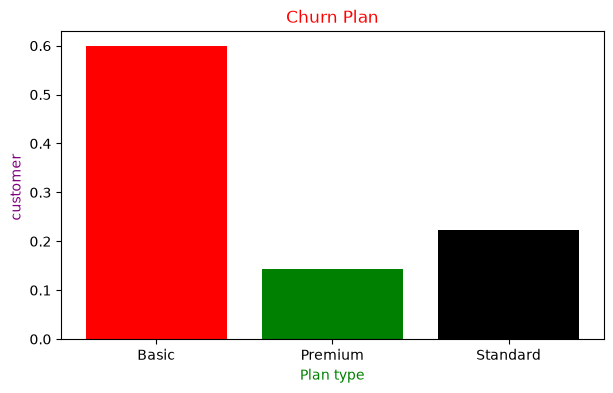

In [82]:
#churn by plan type

churn_plan=df_visual.groupby('plan_type')['churn_flag'].mean()
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index,churn_plan.values,color=['red','green','black'])
plt.title('Churn Plan',color='red')
plt.xlabel('Plan type',color='green')
plt.ylabel('customer ',color='purple')


Text(0, 0.5, 'customer ')

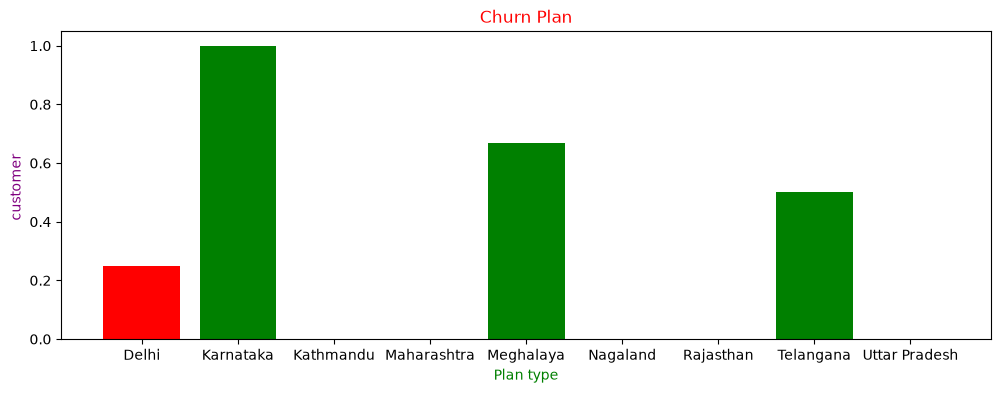

In [83]:
churn_plan=df_visual.groupby('state')['churn_flag'].mean()
plt.figure(figsize=(12,4))
plt.bar(churn_plan.index,churn_plan.values,color=['red','green','black'])
plt.title('Churn Plan',color='red')
plt.xlabel('Plan type',color='green')
plt.ylabel('customer ',color='purple')


In [84]:

#visulaization using seaborn
#before making correlation chat you have to convert string value to numeric
# encoding - convert str to numeric so that we can find corr between features

#incorrect method of encoding - as nummbers are not assigned based on priority
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'customer_age', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [85]:
df_encoding =df_visual[['plan_type','contract_type','churn_risk','churn_flag','escalations']]
categorial_cols=['plan_type','contract_type','churn_risk']
for col in categorial_cols:
    df_encoding[col]=df_encoding[col].astype('category').cat.codes

In [86]:
df_encoding.head()

,plan_type,contract_type,churn_risk,churn_flag,escalations
0,2,0,1,0,0
1,1,0,0,1,1
2,0,1,1,0,0
3,1,0,1,0,0
4,2,1,0,1,1


<Axes: >

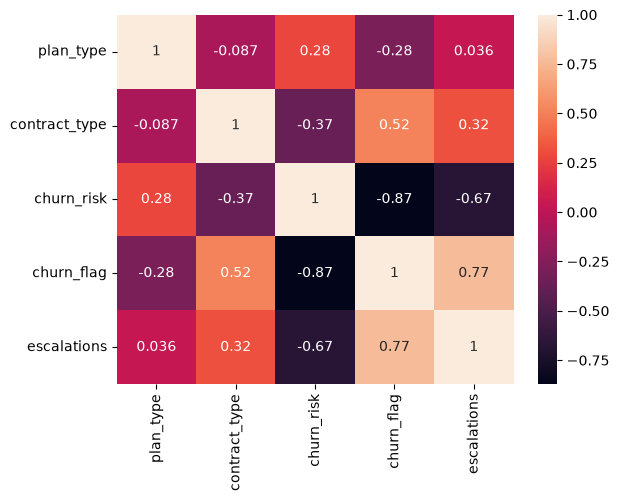

In [87]:
sns.heatmap(df_encoding.corr(),annot=True)

In [88]:
df_visual['contract_type'].unique()

<StringArray>
['Annual', 'Monthly']
Length: 2, dtype: str

In [89]:
#correct method to create heatmap
df_encoding =df_visual[['plan_type','contract_type','churn_risk','churn_flag','escalations']]
order_mapping ={
    'plan_type': ['Basic','Standard','Premium'],
    'contract_type':['Monthly','Annual'],
    'churn_risk':['low','mid','high']
}
for col,order in order_mapping.items():
    df_encoding[col]=pd.Categorical(df_encoding[col].astype('category'),categories=order,ordered=True).codes

<Axes: >

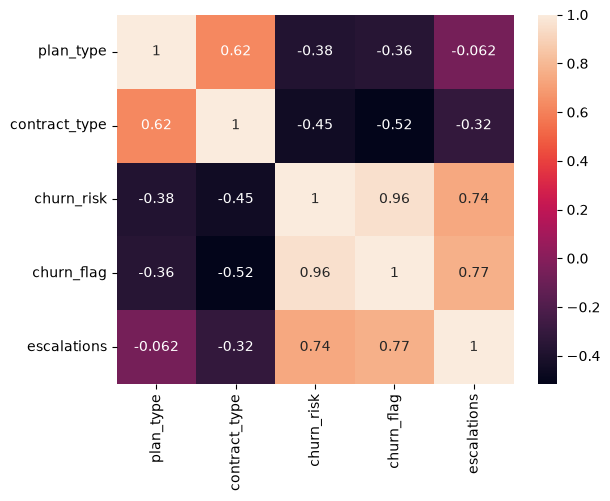

In [90]:
sns.heatmap(df_encoding.corr(),annot=True)

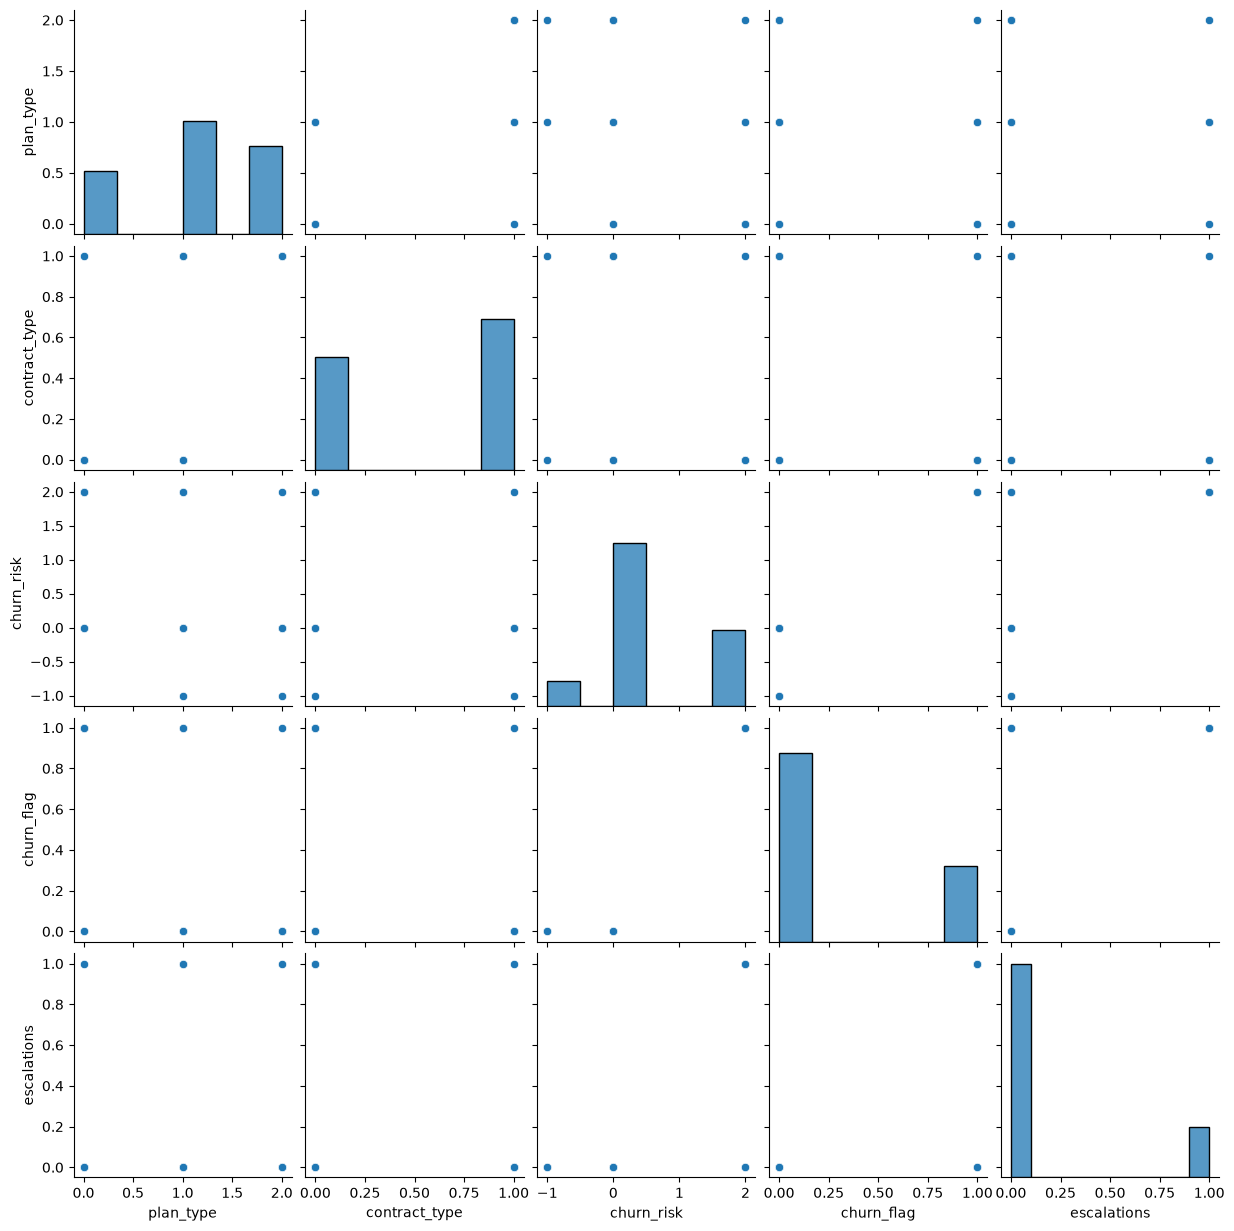

In [91]:
#pairplot -helping in knowing relationship between dataset
sns.pairplot(df_encoding)

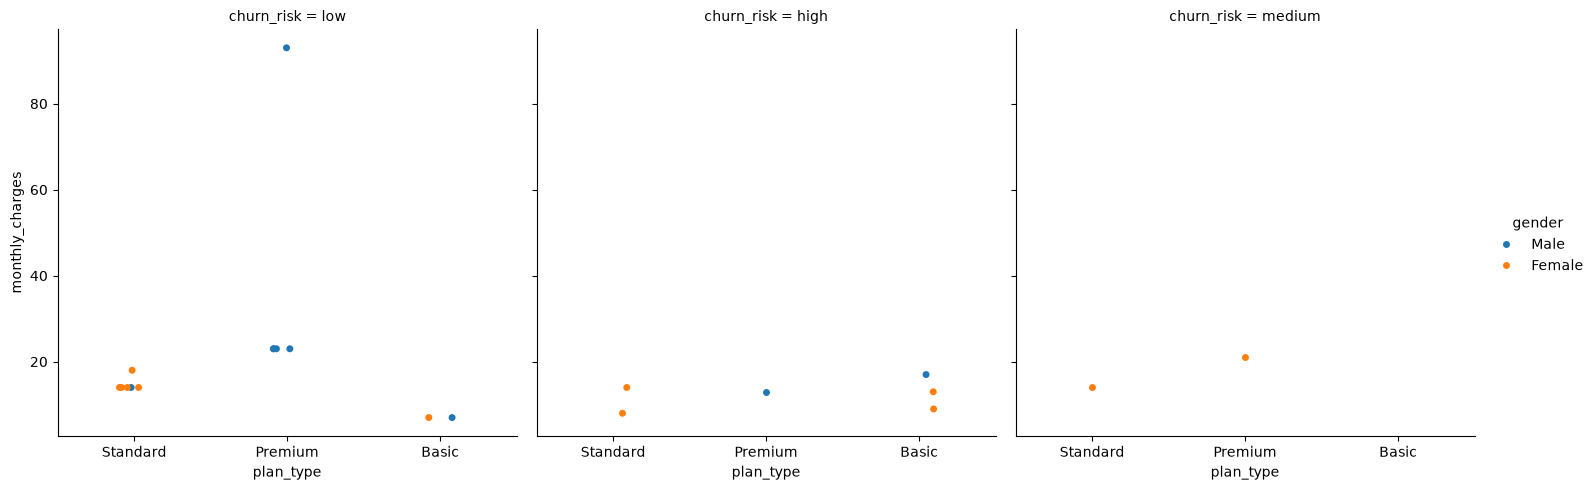

In [92]:
#catplt/facegrid plot
sns.catplot(data=df_visual,
           
           x='plan_type',
           y='monthly_charges',
           hue='gender',
           col='churn_risk')

In [93]:
pd.pivot_table(df_visual,
    values=['monthly_charges','customerid','churn_flag'],
    index='plan_type',
    aggfunc={
        'monthly_charges':'sum',
        'customerid':'nunique',
        'churn_flag':'mean'
    })

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [94]:
#working with sql in pyhton(pandas )


In [96]:
#creating database in sql
conn = sqlite3.connect('creating_database.sqlite')

#table detaile
conn.execute('create table users(first_name Text,country TEXT,budget INTEGER)')
#COMMIT AND SAVE
conn.commit()


OperationalError: table users already exists

In [106]:
#inserting data in table
cursor = conn.cursor()
cursor.execute(
"""
    INSERT INTO users VALUES 
    ('madhav','india',5000),
    ('abhishek','germany',10000),
    ('Ankur','nigeria',500)
    
    """
)
#commit and save
conn.commit()
print('data inserted successfully')

data inserted successfully


In [108]:
conn=sqlite3.connect('creating_database.sqlite')
query='''select * from users '''
df_result=pd.read_sql(query,conn)
df_result

,first_name,country,budget
0,madhav,india,5000
1,abhishek,germany,10000
2,Ankur,nigeria,500


In [112]:
query='''
select country,sum(budget) as toal_budget from users
group by country
'''
df_agg=pd.read_sql(query,conn)
df_agg

,country,toal_budget
0,germany,10000
1,india,5000
2,nigeria,500


In [113]:
conn.close

<function Connection.close()>